In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import TruncatedSVD
from mpl_toolkits.mplot3d import Axes3D

In [3]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values
y = mnist.target.astype(int)

print("Original shape:", X.shape)   # (70000, 784)
print("Image shape:", X[0].reshape(28,28).shape)


Original shape: (70000, 784)
Image shape: (28, 28)


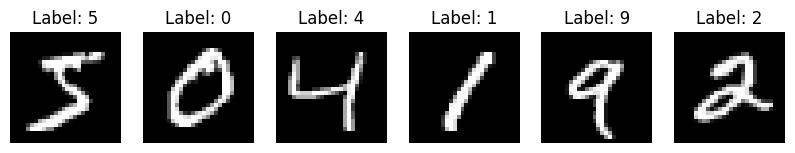

In [4]:
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
print("Shapes of U, S, Vt:", U.shape, S.shape, Vt.shape)


Shapes of U, S, Vt: (70000, 784) (784,) (784, 784)


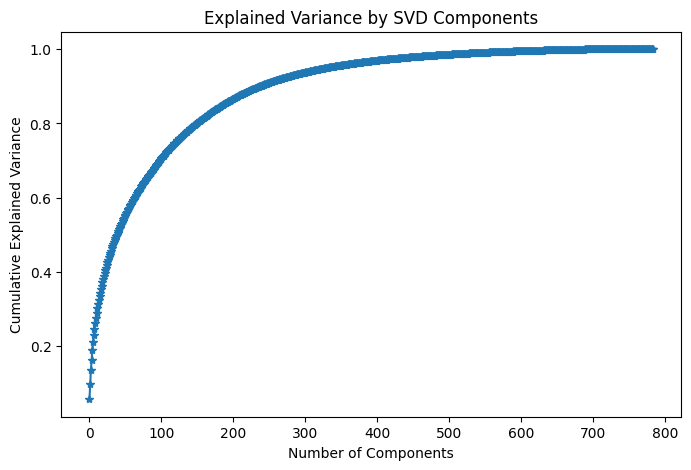

In [7]:
explained_variance = (S ** 2) / np.sum(S ** 2)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='*')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by SVD Components')
plt.show()

In [8]:
k = 100
U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = Vt[:k, :]

X_reduced = U_k @ S_k
print("Reduced shape:", X_reduced.shape)

Reduced shape: (70000, 100)


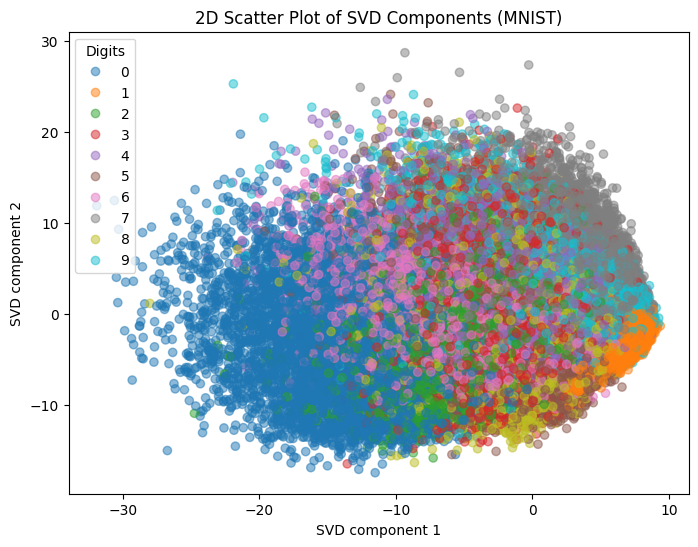

In [9]:
k_scatter = 3
X_2d = U[:, :2] @ np.diag(S[:2])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.5)
plt.xlabel('SVD component 1')
plt.ylabel('SVD component 2')
plt.title('2D Scatter Plot of SVD Components (MNIST)')
plt.legend(*scatter.legend_elements(), title="Digits")
plt.show()

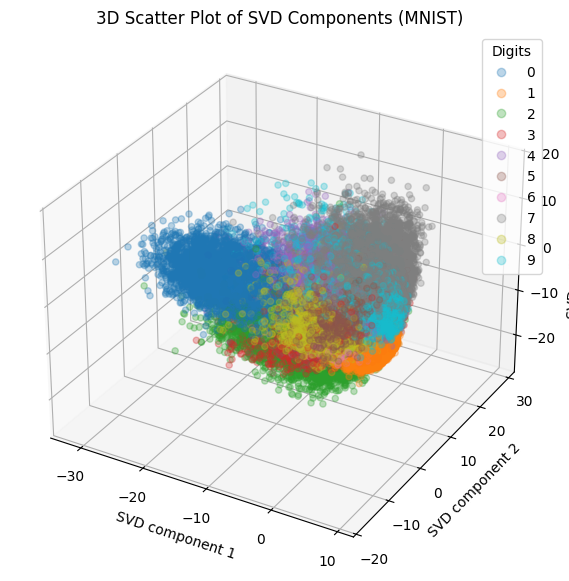

In [10]:
X_3d = U[:, :3] @ np.diag(S[:3])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='tab10', alpha=0.3)
ax.set_xlabel('SVD component 1')
ax.set_ylabel('SVD component 2')
ax.set_zlabel('SVD component 3')
ax.set_title('3D Scatter Plot of SVD Components (MNIST)')
plt.legend(*scatter.legend_elements(), title="Digits")
plt.show()

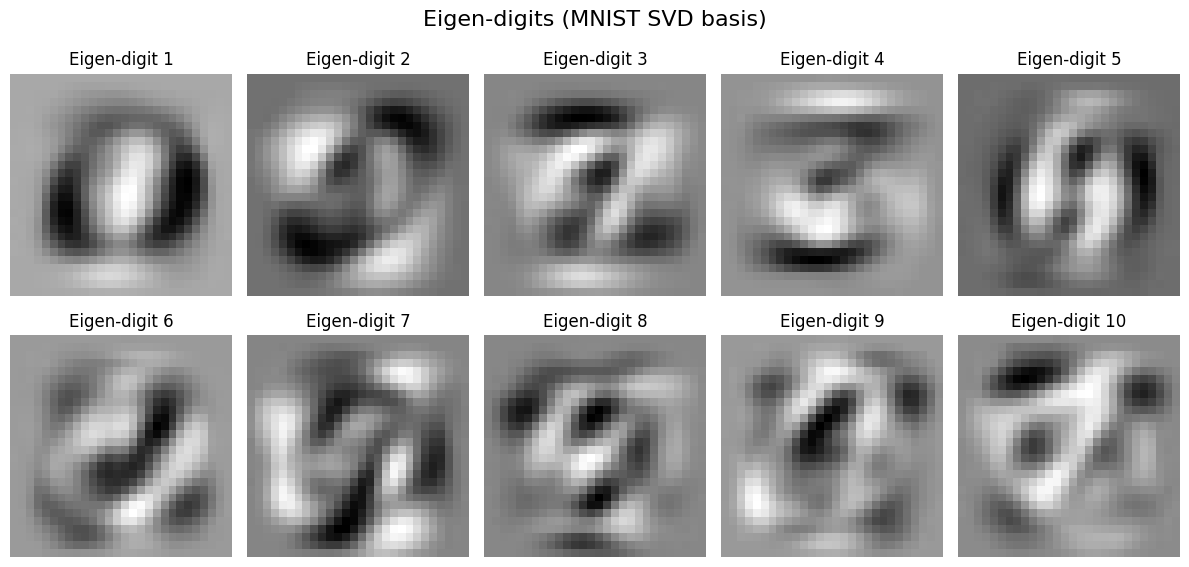

In [11]:
num_eigenvectors = 10
plt.figure(figsize=(12, 6))
for i in range(num_eigenvectors):
    plt.subplot(2, 5, i + 1)
    eigenvector_image = VT_k[i].reshape(28, 28)
    plt.imshow(eigenvector_image, cmap='gray')
    plt.title(f"Eigen-digit {i+1}")
    plt.axis('off')

plt.suptitle('Eigen-digits (MNIST SVD basis)', fontsize=16)
plt.tight_layout()
plt.show()


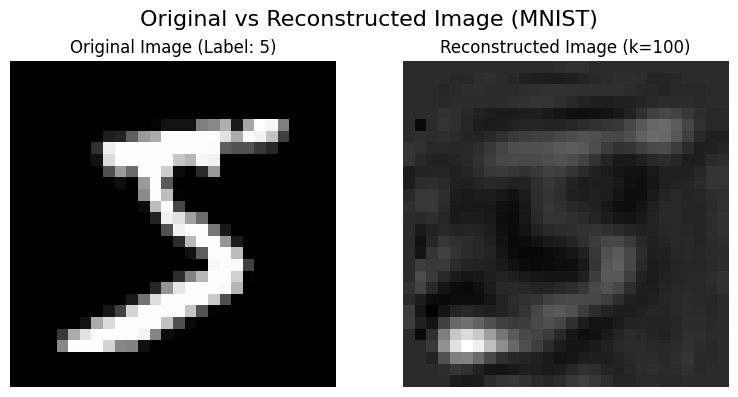

In [12]:
image_index = 0
original_image = X[image_index].reshape(28,28)

reconstructed_image = (U_k[image_index] @ S_k @ VT_k).reshape(28, 28)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title(f"Original Image (Label: {y[image_index]})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title(f"Reconstructed Image (k={k})")
plt.axis('off')

plt.suptitle('Original vs Reconstructed Image (MNIST)', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Without SVD
clf_no_svd = LogisticRegression(max_iter=5000, multi_class="ovr")
clf_no_svd.fit(x_train, y_train)
y_pred_no_svd = clf_no_svd.predict(x_test)
accuracy_no_svd = accuracy_score(y_test, y_pred_no_svd)
print(f"Accuracy WITHOUT SVD: {accuracy_no_svd:.4f}")

# With SVD
svd = TruncatedSVD(n_components=100, random_state=42)
X_train_svd = svd.fit_transform(x_train)
X_test_svd = svd.transform(x_test)

clf_svd = LogisticRegression(max_iter=5000, multi_class="ovr")
clf_svd.fit(X_train_svd, y_train)
y_pred_svd = clf_svd.predict(X_test_svd)
accuracy_svd = accuracy_score(y_test, y_pred_svd)
print(f"Accuracy WITH SVD: {accuracy_svd:.4f}")

c:\Users\kolhe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy WITHOUT SVD: 0.9151


c:\Users\kolhe\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy WITH SVD: 0.9084


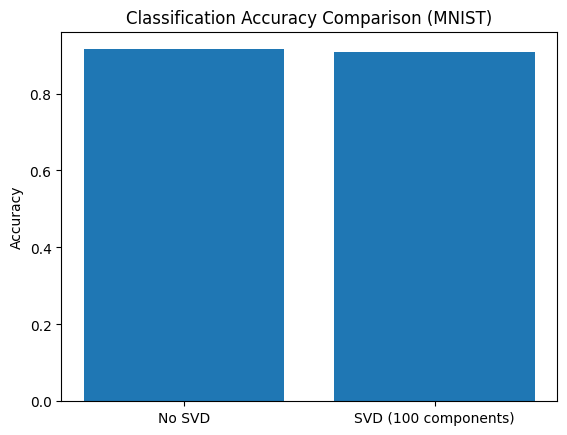

In [14]:
plt.figure()
plt.bar(['No SVD', 'SVD (100 components)'],
        [accuracy_no_svd, accuracy_svd])
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Comparison (MNIST)')
plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_svd)
print(cm)


[[1292    1    5    3    1   12   15    2   10    2]
 [   0 1557    4    7    2   12    1    3   13    1]
 [  10   19 1218   19   17   14   20   18   38    7]
 [   6   12   38 1261    2   41    7   22   27   17]
 [   2    4   11    3 1187    4    9    7   12   56]
 [   8    8   11   63   19 1081   18    7   48   10]
 [   5    5   17    1   12   20 1331    0    5    0]
 [  10    8   24    5   11    4    0 1405    1   35]
 [  11   36   15   51    7   47   14    8 1137   31]
 [  10   10    6   23   42   11    0   56   14 1248]]


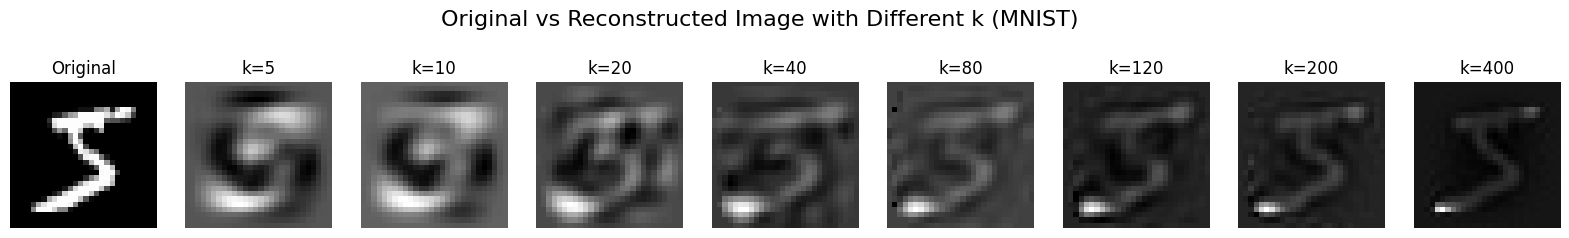

In [16]:
image_index = 0
original_image = X[image_index].reshape(28, 28)

k_values = [5, 10, 20, 40, 80, 120, 200, 400]

plt.figure(figsize=(20, 3))

# Original Image
plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original")
plt.axis('off')

# Reconstructions
for i, k in enumerate(k_values):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = Vt[:k, :]
    
    reconstructed_image = (U_k[image_index] @ S_k @ VT_k).reshape(28, 28)
    
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(reconstructed_image, cmap='gray')
    plt.title(f"k={k}")
    plt.axis('off')

plt.suptitle('Original vs Reconstructed Image with Different k (MNIST)', fontsize=16)
plt.show()